# 05 — Goodness-of-fit: across-station p-values, seasonal maps, and simulation check

Produces:
- `figures/pvalue_maps_by_season_geom_vs_bmcd.pdf` (Fig. 13) — spatial map per season.
- `figures/gof_Qn_and_pvalues_simulated_data.pdf` (Fig. A, appendix) — null-distribution validity check.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))
import json
import numpy as np
import pandas as pd
from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *
from article_code.util_files.statistics import *
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)
list_cities = sorted(spells.keys())
stations = pd.read_csv(config.STATION_METADATA_CSV)
df_info = stations[stations.city.isin(list_cities)]

In [2]:
# hdeGPD on real data
dict_chi2_true, dict_p_true, dict_D_true, rejected_egpd = goodness_of_fit_true_all_cities_seasons(
    data=spells, df_fit=df_fit_dry, nb_days_min_for_D=20, force_D=None, spell_type="dry",
)
df_gof_true_hdegpd = build_gof_results_df(dict_chi2_true, dict_p_true, dict_D_true, df_info)

# Geometric baseline on real data
dict_chi2_g, dict_p_g, dict_D_g, dict_p_hat_g, rejected_geom = \
    goodness_of_fit_true_all_cities_seasons_geometric(
        data=spells, nb_days_min_for_D=20, force_D=None, spell_type="dry",
    )
df_gof_true_geom = build_gof_results_df(dict_chi2_g, dict_p_g, dict_D_g, df_info)

df_gof_true_hdegpd.head()

100%|██████████| 209/209 [00:56<00:00,  3.67it/s]


,city,season,Q_n,p_value,D,country,lat,lon
0,ACHTOPOL,autumn,20.809146,0.076790,14,BG,42.100000,27.850000
1,AGLIENTU,autumn,23.551377,0.213927,20,IT,41.078056,9.112778
2,AGUIAR DA BEIRA,autumn,25.619720,0.372738,25,PT,40.810000,-7.540000
3,AJACCIO,autumn,28.764894,0.119761,22,FR,41.918056,8.792778
4,AKHISAR,autumn,33.615512,0.213819,29,TR,38.808889,27.833889


## Fig. 13 — Spatial maps of p-values per season (large = geometric, small = hdeGPD)

In [3]:
fig = plotting.plot_pvalue_maps_by_season(
    df_gof_bmcd=df_gof_true_hdegpd,
    df_gof_baseline=df_gof_true_geom,
    seasons=("spring", "summer", "autumn", "winter"),
    label_model="hdeGPD model",
    label_baseline="Geometric model",
    vmin=1e-7,
    zoom=3.5,
)
fig.show()
plotting.save_pvalue_maps_by_season(fig)

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/pvalue_maps_by_season_geom_vs_bmcd.pdf')

## Fig. A — Null-distribution check on simulated data (Proposition 4)

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import chi2


def goodness_of_fit_for_simulated_sample(simulated_durations, f_1, xi_gpd, sigma_gpd, kappa_gpd,
                                         nb_days_min_for_D=40, force_D=None):
    days, probas_emp, nb_days_state_list = get_proba_leaving_by_day(simulated_durations)
    if force_D is not None:
        D = force_D
    else:
        D = adaptive_D(nb_days_state_list, nb_days_min_for_D)
        if D < 2:
            return None
    cdf_fitted = make_cdf_fitted_hdeGPD_from_params(f_1, xi_gpd, sigma_gpd, kappa_gpd)
    fitted_probas_extgpd = np.array(
        [get_proba_leaving_state_n_kozu(cdf_fitted, d) for d in range(1, D)], dtype=float)
    probas_emp = np.asarray(probas_emp, dtype=float)[:D - 1]
    T = build_T_matrix(D, cdf_fitted)
    Sigma = build_Sigma_matrix_new(D, cdf_fitted)
    inv_matrix_mul = np.linalg.inv(T @ Sigma @ T.T)
    diff = probas_emp - fitted_probas_extgpd
    N_cycles = len(simulated_durations)
    Q_n = float(N_cycles * diff.T @ inv_matrix_mul @ diff)
    p_val = 1.0 - scipy.stats.chi2.cdf(Q_n, df=D - 1)
    return Q_n, p_val

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/gof_Qn_and_pvalues_simulated_data.pdf')

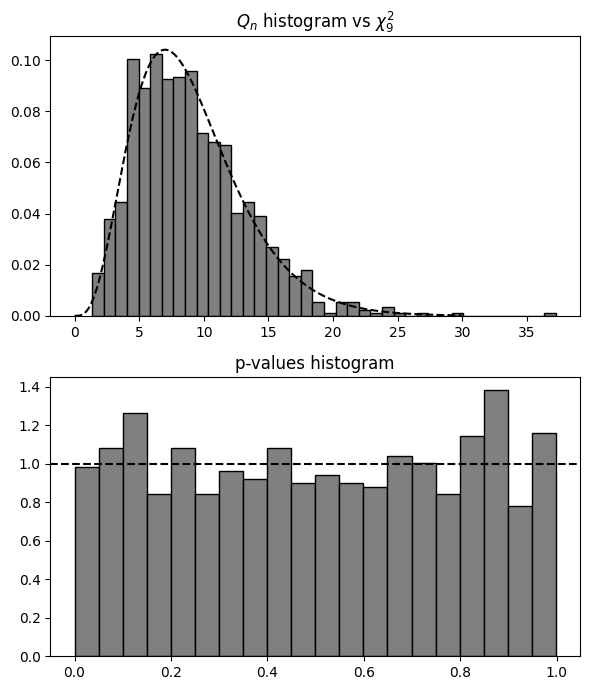

In [5]:
D_MAX = 10
n_rep = 1000
row = df_fit_dry.iloc[0]
Qs, ps = [], []
for _ in range(n_rep):
    # sim = sm.simulate_season_durations_from_fit(n=500, proba1=row['f1'], xi_gpd=row['xi'],
    #                                              sigma_gpd=row['sigma'], kappa_gpd=row['kappa'])
    sim = [get_spell_length_degenerate_mixture_order_1_extgpd1(xi_gpd=row['xi'], sigma_gpd=row['sigma'], kappa_gpd=row['kappa'],f_1=row['f_1'])
           for i in range(500)]
    Q, p = goodness_of_fit_for_simulated_sample(sim, row['f_1'], row['xi'], row['sigma'], row['kappa'],
                                                     nb_days_min_for_D=20, force_D=D_MAX)
    Qs.append(Q); ps.append(p)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7))
x = np.linspace(0, 30, 200)
ax1.hist(Qs, bins=40, density=True, color='grey', edgecolor='k')
ax1.plot(x, chi2.pdf(x, D_MAX - 1), 'k--')
ax1.set_title(r'$Q_n$ histogram vs $\chi^2_{%d}$' % (D_MAX - 1))
ax2.hist(ps, bins=20, density=True, color='grey', edgecolor='k')
ax2.axhline(1, color='k', ls='--')
ax2.set_title('p-values histogram')
fig.tight_layout()
plotting.save_gof_simulation(fig)